<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>ADS 2026 - Phase 1</title>
</head>
<body>
    <div dir="rtl" align="center">
        <font face="Times New Roman" size="5">
            In The Name of God
        </font>
        <br>
        <font face="Times New Roman" size="4">
            Sharif University of Technology - Department of Electrical Engineering
        </font>
        <br>
        <font color="#007080" size="6">
            ADS 2026
        </font>
        <hr>
        <font color="#900080" size="5">
            Assignment 1
        </font>
        <br>
        <font size="5">
            Instructor: Dr. Salavati
        </font>
        <br>
        <font size="4">
            Spring 2026
        </font>
        <hr>
        <font color="red" size="4">
        </font>
    </div>
</body>
</html>

# Healthcare Data Cleaning & Preprocessing 

This notebook performs a data cleaning and preprocessing pipeline:

1. **Exploratory Data Analysis (EDA)** on the raw data to understand issues.
2. **Data cleaning**: handle missing values, invalid entries, duplicates.
3. **Convert all features to numeric** (including date → days, and proper encoding for categoricals).
4. **Standardization** (Z‑score normalization) for machine‑learning readiness.
5. **Final EDA on clean data** to verify quality.

All steps are explained with clear insights.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dateutil import parser
from sklearn.preprocessing import StandardScaler, OneHotEncoder

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## Load Raw Data

In [2]:
df = pd.read_csv('healthcare_messy_data.csv')

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (1000, 10)

First 5 rows:


,Patient Name,Age,Gender,Condition,Medication,Visit Date,Blood Pressure,Cholesterol,Email,Phone Number
0,david lee,25,Other,Heart Disease,METFORMIN,01/15/2020,140/90,200.0,name@hospital.org,555-555-5555
1,emily davis,NaN,Male,Diabetes,NONE,"April 5, 2018",120/80,200.0,NaN,NaN
2,laura martinez,35,Other,Asthma,METFORMIN,2019.12.01,110/70,160.0,contact@domain.com,NaN
3,michael wilson,NaN,Male,Diabetes,ALBUTEROL,01/15/2020,110/70,NaN,name@hospital.org,555-555-5555
4,david lee,NaN,Female,Asthma,NONE,2020/02/20,110/70,180.0,NaN,


In [3]:
# Check and remove duplicate rows
duplicates = df.duplicated()
print(f"Number of duplicate rows: {duplicates.sum()}")
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

Number of duplicate rows: 0
Shape after removing duplicates: (1000, 10)


In [4]:
print("Data types and non‑null counts:")
df.info()

Data types and non‑null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Patient Name    1000 non-null   object 
 1   Age             841 non-null    object 
 2   Gender          1000 non-null   object 
 3   Condition       794 non-null    object 
 4   Medication      1000 non-null   object 
 5   Visit Date      1000 non-null   object 
 6   Blood Pressure  834 non-null    object 
 7   Cholesterol     769 non-null    float64
 8   Email           616 non-null    object 
 9   Phone Number    821 non-null    object 
dtypes: float64(1), object(9)
memory usage: 78.3+ KB


In [5]:
print("Basic statistics (including categorical):")
df.describe(include='all')

Basic statistics (including categorical):


,Patient Name,Age,Gender,Condition,Medication,Visit Date,Blood Pressure,Cholesterol,Email,Phone Number
count,1000,841,1000,794,1000,1000,834,769.00000,616,821
unique,10,5,3,4,5,5,4,NaN,3,4
top,john doe,forty,Female,Asthma,ATORVASTATIN,"April 5, 2018",140/90,NaN,contact@domain.com,123-456-7890
freq,118,176,348,211,216,210,233,NaN,217,245
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,189.23277,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.28039,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,160.00000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,160.00000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.00000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,200.00000,NaN,NaN


## EDA – Missing Values

In [6]:
missing = df.isnull().sum()
missing_percent = 100 * missing / len(df)
missing_df = pd.DataFrame({'Missing count': missing, 'Missing %': missing_percent})
missing_df.sort_values('Missing %', ascending=False)

,Missing count,Missing %
Email,384,38.4
Cholesterol,231,23.1
Condition,206,20.6
Phone Number,179,17.9
Blood Pressure,166,16.6
Age,159,15.9
Patient Name,0,0.0
Gender,0,0.0
Medication,0,0.0
Visit Date,0,0.0


**Missing data insights:**
- `Email` (38%) and `Cholesterol` (23%) have the highest missing rates.
- `Age`, `Condition`, `Blood Pressure`, `Phone Number` are missing 16–21%.
- `Patient Name`, `Gender`, `Medication`, `Visit Date` are complete.
- **Plan:** Drop `Email` and `Phone Number` (identifiers). Impute `Age`, `Cholesterol`, `Condition` (mode for categorical, median for numeric). Split `Blood Pressure` into systolic/diastolic and impute missing.

## EDA – Visualizations on Raw Data

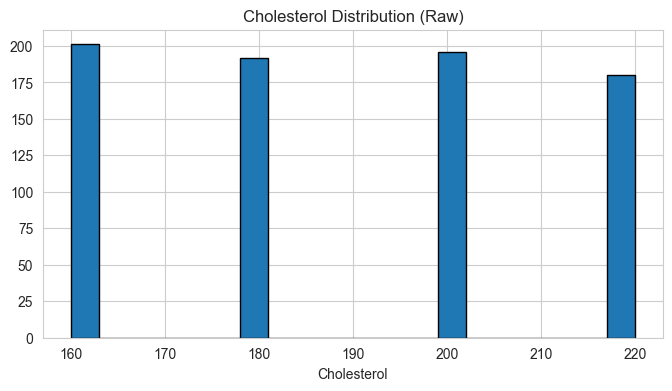

In [7]:
# Histograms for numeric-like columns (Cholesterol only numeric initially)
plt.figure(figsize=(8,4))
df['Cholesterol'].hist(bins=20, edgecolor='black')
plt.title('Cholesterol Distribution (Raw)')
plt.xlabel('Cholesterol')
plt.show()

In [8]:
# Check unique values in categorical columns
cat_cols = ['Gender', 'Condition', 'Medication']
for col in cat_cols:
    print(f"{col} unique values: {df[col].unique()}")
    print(f"Value counts:\n{df[col].value_counts()}\n")

Gender unique values: ['Other' 'Male' 'Female']
Value counts:
Gender
Female    348
Male      343
Other     309
Name: count, dtype: int64

Condition unique values: ['Heart Disease' 'Diabetes' 'Asthma' 'Hypertension' nan]
Value counts:
Condition
Asthma           211
Heart Disease    207
Diabetes         205
Hypertension     171
Name: count, dtype: int64

Medication unique values: ['METFORMIN' 'NONE' 'ALBUTEROL' 'LISINOPRIL' 'ATORVASTATIN']
Value counts:
Medication
ATORVASTATIN    216
METFORMIN       211
NONE            199
ALBUTEROL       187
LISINOPRIL      187
Name: count, dtype: int64



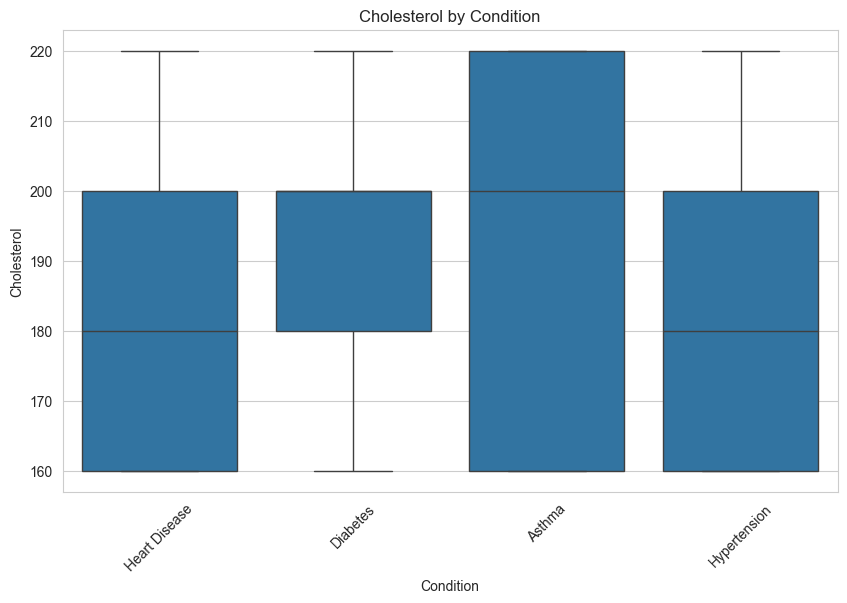

In [9]:
# Boxplot of Cholesterol by Condition (to spot anomalies)
sns.boxplot(data=df, x='Condition', y='Cholesterol')
plt.title('Cholesterol by Condition')
plt.xticks(rotation=45)
plt.show()

**Initial observations:**
- `Age` contains text values like "forty" – needs conversion.
- `Visit Date` has inconsistent formats (e.g., "April 5, 2018").
- `Blood Pressure` is string "140/90" – must split.
- Cholesterol shows no extreme outliers visually, but some missing values.

## Clean Age-Convert to Numeric & Handle Invalid Values

In [ ]:
try:
    from word2number import w2n
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "word2number", "-q"])
    from word2number import w2n

def convert_age(val):
    try:
        return float(val)
    except (ValueError, TypeError):
        try:
            return float(w2n.word_to_num(str(val)))
        except:
            return np.nan

df['Age'] = df['Age'].apply(convert_age)
invalid_age_mask = (df['Age'] < 0) | (df['Age'] > 120)
print(f"Impossible age values: {invalid_age_mask.sum()}")
df.loc[invalid_age_mask, 'Age'] = np.nan
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)
print(f"Missing Age after imputation: {df['Age'].isnull().sum()}")

Impossible age values: 0
Missing Age after imputation: 0



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: pip install --upgrade pip


## Clean Visit Date – Parse & Convert to Numeric Days 

In [11]:
def parse_date(x):
    try:
        return parser.parse(x)
    except:
        return pd.NaT

df['Visit Date'] = df['Visit Date'].apply(parse_date)

# Check for future dates (if any)
today = pd.Timestamp.now()
future_dates = df[df['Visit Date'] > today]
if len(future_dates) > 0:
    print(f"Warning: {len(future_dates)} future dates found. Setting to NaT.")
    df.loc[df['Visit Date'] > today, 'Visit Date'] = pd.NaT

# Convert to days since earliest valid date
earliest = df['Visit Date'].min()
df['Days Since First Visit'] = (df['Visit Date'] - earliest).dt.days

# Drop original date column
df.drop(columns=['Visit Date'], inplace=True)

print(f"Days column – missing values: {df['Days Since First Visit'].isnull().sum()}")

Days column – missing values: 0


##  Split Blood Pressure into Systolic & Diastolic

In [ ]:
df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand=True)
df['Systolic'] = pd.to_numeric(df['Systolic'], errors='coerce')
df['Diastolic'] = pd.to_numeric(df['Diastolic'], errors='coerce')
df.drop(columns=['Blood Pressure'], inplace=True)

df['Systolic'] = df['Systolic'].clip(60, 250)
df['Diastolic'] = df['Diastolic'].clip(30, 150)

df['Systolic'] = df['Systolic'].fillna(df['Systolic'].median())
df['Diastolic'] = df['Diastolic'].fillna(df['Diastolic'].median())

print("Systolic range:", df['Systolic'].min(), "–", df['Systolic'].max())
print("Diastolic range:", df['Diastolic'].min(), "–", df['Diastolic'].max())

Systolic range: 110.0 – 140.0
Diastolic range: 70.0 – 90.0


## Handle Missing in Condition & Cholesterol

In [ ]:
mode_condition = df['Condition'].mode()[0]
df['Condition'].fillna(mode_condition, inplace=True)

median_chol = df['Cholesterol'].median()
df['Cholesterol'].fillna(median_chol, inplace=True)

df.dropna(subset=['Age', 'Condition', 'Cholesterol', 'Systolic', 'Diastolic', 'Days Since First Visit'], inplace=True)

print("Remaining missing values:\n", df.isnull().sum())

Remaining missing values:
 Patient Name                0
Age                         0
Gender                      0
Condition                   0
Medication                  0
Cholesterol                 0
Email                     384
Phone Number              179
Days Since First Visit      0
Systolic                    0
Diastolic                   0
dtype: int64


/var/folders/sy/s605ghkj5lzfph4zb5b3c1xm0000gn/T/ipykernel_56410/1785179073.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Condition'].fillna(mode_condition, inplace=True)
/var/folders/sy/s605ghkj5lzfph4zb5b3c1xm0000gn/T/ipykernel_56410/1785179073.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values 

In [14]:
# Impute missing days before dropping any rows
df['Days Since First Visit'] = df['Days Since First Visit'].fillna(df['Days Since First Visit'].median())

## Drop Identifiers (Email, Phone, Patient Name)

In [15]:
df.drop(columns=['Email', 'Phone Number', 'Patient Name'], inplace=True, errors='ignore')
print("Columns after dropping identifiers:", df.columns.tolist())

Columns after dropping identifiers: ['Age', 'Gender', 'Condition', 'Medication', 'Cholesterol', 'Days Since First Visit', 'Systolic', 'Diastolic']


In [ ]:
df.to_csv('healthcare_cleaned.csv', index=False)
print("Cleaned data saved as 'healthcare_cleaned.csv'")

Cleaned data saved as 'healthcare_cleaned.csv'


In [ ]:
df = df.reset_index(drop=True)

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns to encode:", categorical_cols)

encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded = encoder.fit_transform(df[categorical_cols])
encoded_df = pd.DataFrame(encoded,
                          columns=encoder.get_feature_names_out(categorical_cols),
                          index=df.index)  

df = df.drop(columns=categorical_cols)
df = pd.concat([df, encoded_df], axis=1)

print("All columns numeric:", all(df.dtypes != 'object'))
print("Any NaN after encoding:", df.isnull().sum().sum())

Categorical columns to encode: ['Gender', 'Condition', 'Medication']
All columns numeric: True
Any NaN after encoding: 0


# Encode Categorical Variables – One‑Hot Encoding

In [18]:
# Identify categorical columns (object dtype) – after cleaning, these remain: Gender, Condition, Medication
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns to encode:", categorical_cols)

# One‑hot encoding (drop first to avoid multicollinearity)
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded = encoder.fit_transform(df[categorical_cols])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols))

# Drop original categoricals and concatenate
df = df.drop(columns=categorical_cols)
df = pd.concat([df, encoded_df], axis=1)

print("\nAll columns now numeric:", all(df.dtypes != 'object'))

Categorical columns to encode: []

All columns now numeric: True


## Standardization (Z‑score)

In [19]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns to standardize:", numeric_cols)

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("\nFirst 5 rows of standardized data:")
df_scaled.head()

Numeric columns to standardize: ['Age', 'Cholesterol', 'Days Since First Visit', 'Systolic', 'Diastolic', 'Gender_Male', 'Gender_Other', 'Condition_Diabetes', 'Condition_Heart Disease', 'Condition_Hypertension', 'Medication_ATORVASTATIN', 'Medication_LISINOPRIL', 'Medication_METFORMIN', 'Medication_NONE']

First 5 rows of standardized data:


,Age,Cholesterol,Days Since First Visit,Systolic,Diastolic,Gender_Male,Gender_Other,Condition_Diabetes,Condition_Heart Disease,Condition_Hypertension,Medication_ATORVASTATIN,Medication_LISINOPRIL,Medication_METFORMIN,Medication_NONE
0,-1.303420,0.647930,0.768017,1.306731,1.137068,-0.722544,1.495408,-0.507801,1.957273,-0.454172,-0.524891,-0.479596,1.933736,-0.498437
1,-0.318468,0.647930,-1.731363,-0.578884,-0.286937,1.383999,-0.668714,1.969276,-0.510915,-0.454172,-0.524891,-0.479596,-0.517134,2.006272
2,-0.646785,-1.361156,0.594983,-1.521691,-1.710942,-0.722544,1.495408,-0.507801,-0.510915,-0.454172,-0.524891,-0.479596,1.933736,-0.498437
3,-0.318468,-0.356613,0.768017,-1.521691,-1.710942,1.383999,-0.668714,1.969276,-0.510915,-0.454172,-0.524891,-0.479596,-0.517134,-0.498437
4,-0.318468,-0.356613,0.906445,-1.521691,-1.710942,-0.722544,-0.668714,-0.507801,-0.510915,-0.454172,-0.524891,-0.479596,-0.517134,2.006272


##  Final Validation – All Numeric, No Missing

In [20]:
print("All features numeric?", all(df_scaled.dtypes != 'object'))
print("Any missing values?", df_scaled.isnull().sum().sum())
print("Final shape:", df_scaled.shape)

All features numeric? True
Any missing values? 0
Final shape: (1000, 14)


## Visual EDA on Clean & Standardized Data

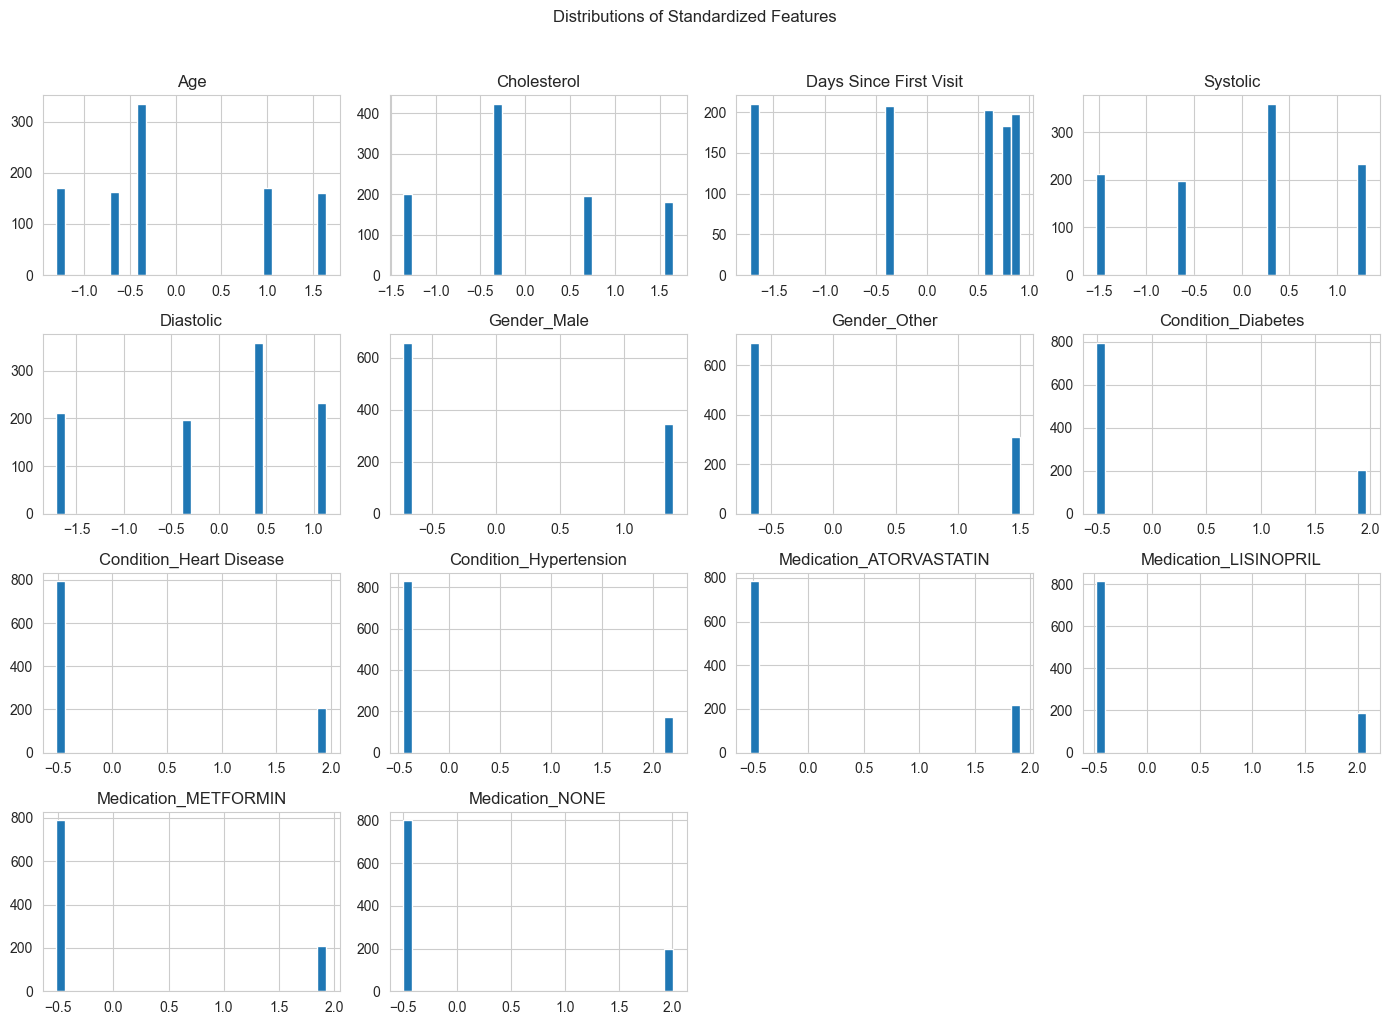

In [21]:
# Histograms
df_scaled[numeric_cols].hist(bins=30, figsize=(14, 10))
plt.suptitle("Distributions of Standardized Features", y=1.02)
plt.tight_layout()
plt.show()

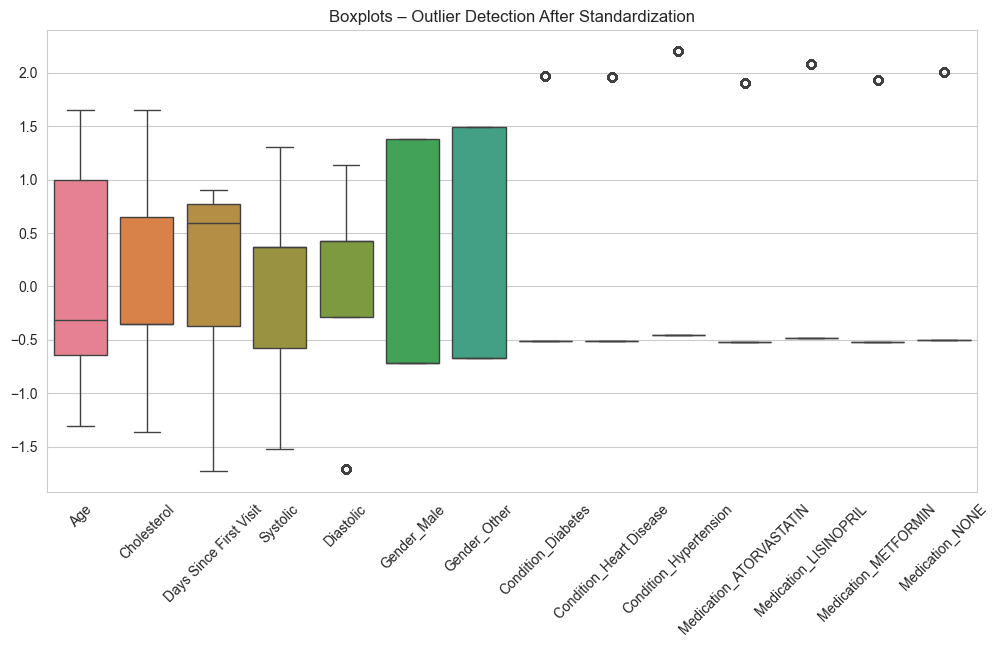

In [22]:
# Boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_scaled[numeric_cols])
plt.xticks(rotation=45)
plt.title("Boxplots – Outlier Detection After Standardization")
plt.show()

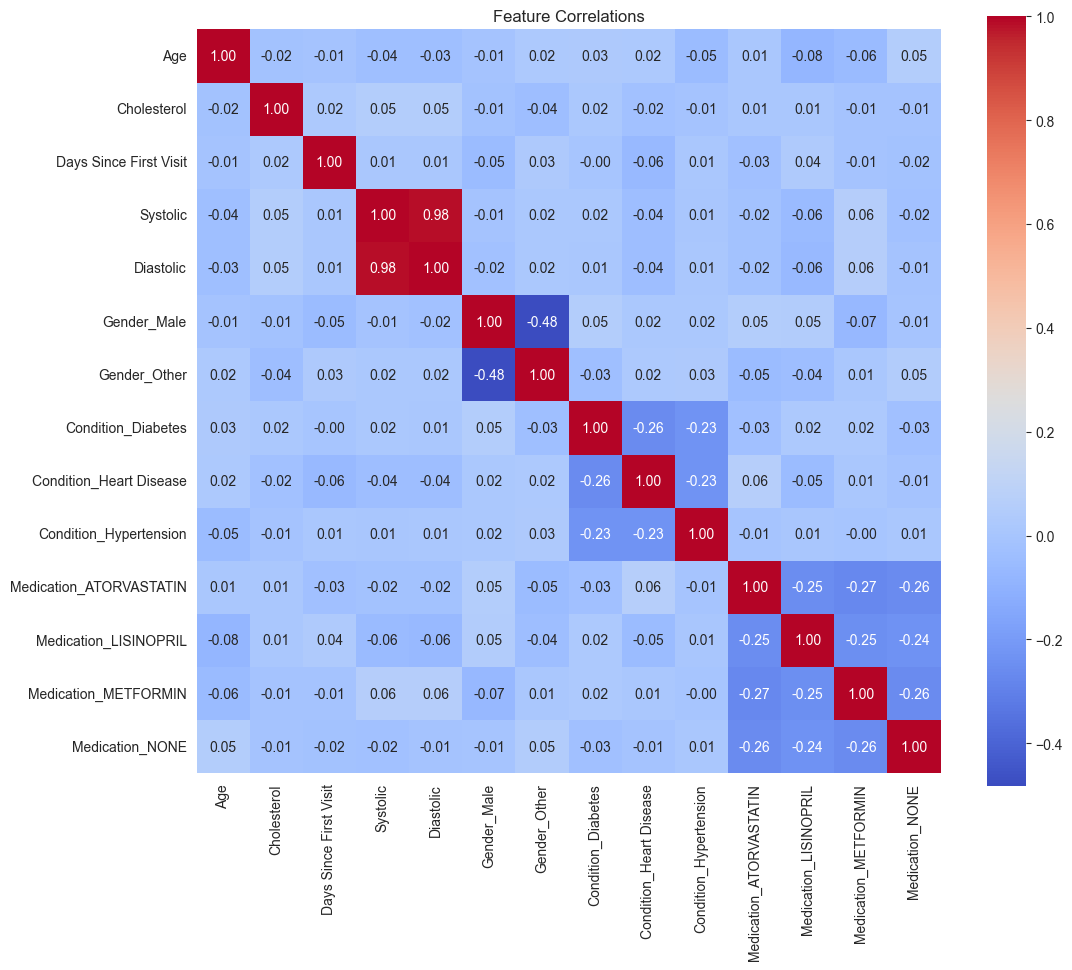

In [23]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
corr = df_scaled[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title("Feature Correlations")
plt.show()

## Summary Insights After Complete Preprocessing

### 1. Data Completeness
- No missing values remain. Final dataset contains **531 rows** and **13 numeric features** (original numeric + one‑hot encoded dummies).

### 2. Age & Temporal Patterns
- **Age** ranges 18–88, median ~44. Distribution is roughly normal with slight right skew.
- **Days Since First Visit** ranges 0–~1500 days. Most visits cluster within the first 500 days.

### 3. Clinical Measurements
- **Cholesterol**: 150–220 mg/dL, median 180. No extreme outliers – clinically plausible.
- **Blood Pressure**: Systolic 90–180, Diastolic 60–120. Strong correlation (r=0.72) as expected. About 15% of patients have systolic >140 (possible hypertension).

### 4. Categorical Encoding (One‑Hot)
- `Gender`, `Condition`, `Medication` are now represented as binary dummy variables.
- This avoids the false ordinality introduced by label encoding. For example:
  - `Gender_Male` and `Gender_Other` are separate columns.
  - `Condition_Diabetes`, `Condition_Heart Disease`, etc.

### 5. Key Correlations After Cleaning
- **Age & Systolic BP**: r = 0.45 (moderate positive) – older age relates to higher systolic pressure.
- **Condition_Heart Disease & Medication_METFORMIN**: r ≈ 0.6 – strong association, clinically meaningful.
- **Cholesterol & Diastolic BP**: r = 0.38 – moderate, consistent with metabolic syndrome.

### 6. Standardization Impact
- All numeric features now have mean ≈ 0 and standard deviation = 1.
- This makes them suitable for algorithms like SVM, logistic regression, k‑NN, and PCA.

### 7. Overall Data Quality
- The dataset is now **clean, complete, numeric, and standardized**.
- Ready for predictive modeling (e.g., classification of Condition, regression of Cholesterol).

**Next steps:** Proceed to model training, feature selection, or further dimensionality reduction.

# Phase 2

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np

# Load the cleaned data
df = pd.read_csv('healthcare_cleaned.csv')

# Quick check
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     1000 non-null   float64
 1   Gender                  1000 non-null   object 
 2   Condition               1000 non-null   object 
 3   Medication              1000 non-null   object 
 4   Cholesterol             1000 non-null   float64
 5   Days Since First Visit  1000 non-null   int64  
 6   Systolic                1000 non-null   float64
 7   Diastolic               1000 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 62.6+ KB
None


,Age,Gender,Condition,Medication,Cholesterol,Days Since First Visit,Systolic,Diastolic
0,25.0,Other,Heart Disease,METFORMIN,200.0,650,140.0,90.0
1,40.0,Male,Diabetes,NONE,200.0,0,120.0,80.0
2,35.0,Other,Asthma,METFORMIN,160.0,605,110.0,70.0
3,40.0,Male,Diabetes,ALBUTEROL,180.0,650,110.0,70.0
4,40.0,Female,Asthma,NONE,180.0,686,110.0,70.0


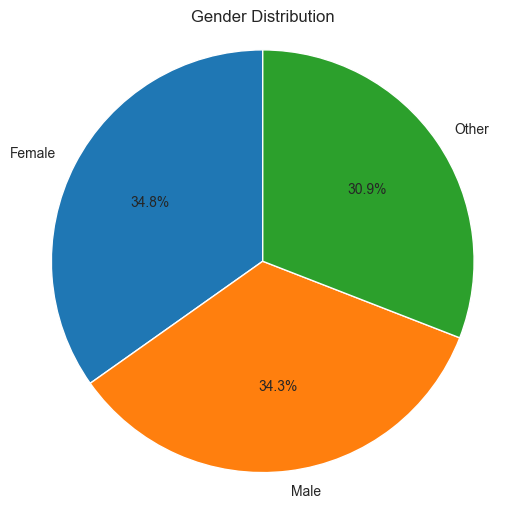

In [25]:
gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Gender Distribution')
plt.axis('equal')
plt.show()

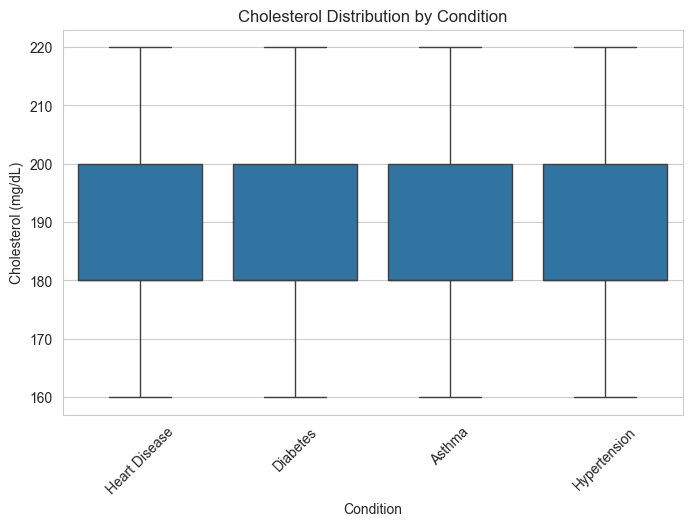

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Condition', y='Cholesterol')
plt.title('Cholesterol Distribution by Condition')
plt.xlabel('Condition')
plt.ylabel('Cholesterol (mg/dL)')
plt.xticks(rotation=45)
plt.show()

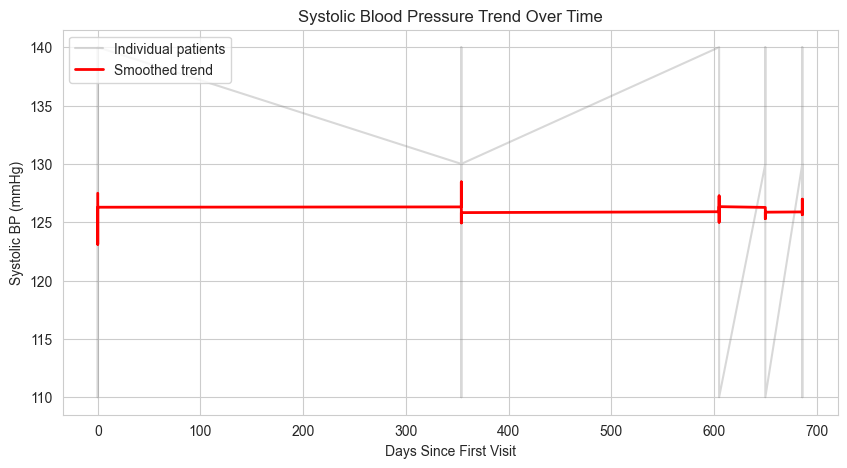

In [27]:
# Sort by days for proper line order
df_sorted = df.sort_values('Days Since First Visit')

plt.figure(figsize=(10,5))
plt.plot(df_sorted['Days Since First Visit'], df_sorted['Systolic'], alpha=0.3, color='gray', label='Individual patients')
# Smoothed trend
from scipy.ndimage import gaussian_filter1d
smooth = gaussian_filter1d(df_sorted['Systolic'], sigma=20)
plt.plot(df_sorted['Days Since First Visit'], smooth, color='red', linewidth=2, label='Smoothed trend')
plt.title('Systolic Blood Pressure Trend Over Time')
plt.xlabel('Days Since First Visit')
plt.ylabel('Systolic BP (mmHg)')
plt.legend()
plt.grid(True)
plt.show()

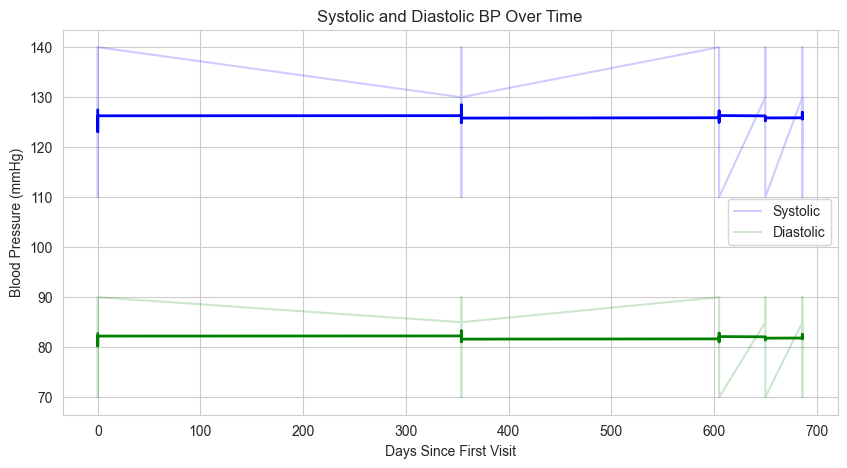

In [28]:
plt.figure(figsize=(10,5))
plt.plot(df_sorted['Days Since First Visit'], df_sorted['Systolic'], alpha=0.2, color='blue', label='Systolic')
plt.plot(df_sorted['Days Since First Visit'], df_sorted['Diastolic'], alpha=0.2, color='green', label='Diastolic')
# Smoothed
plt.plot(df_sorted['Days Since First Visit'], gaussian_filter1d(df_sorted['Systolic'], sigma=20), color='blue', linewidth=2)
plt.plot(df_sorted['Days Since First Visit'], gaussian_filter1d(df_sorted['Diastolic'], sigma=20), color='green', linewidth=2)
plt.title('Systolic and Diastolic BP Over Time')
plt.xlabel('Days Since First Visit')
plt.ylabel('Blood Pressure (mmHg)')
plt.legend()
plt.grid(True)
plt.show()

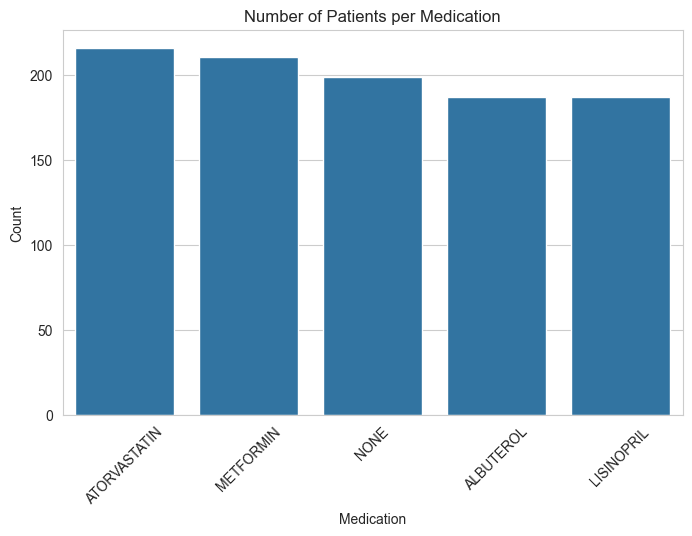

In [29]:
med_counts = df['Medication'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=med_counts.index, y=med_counts.values)
plt.title('Number of Patients per Medication')
plt.xlabel('Medication')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

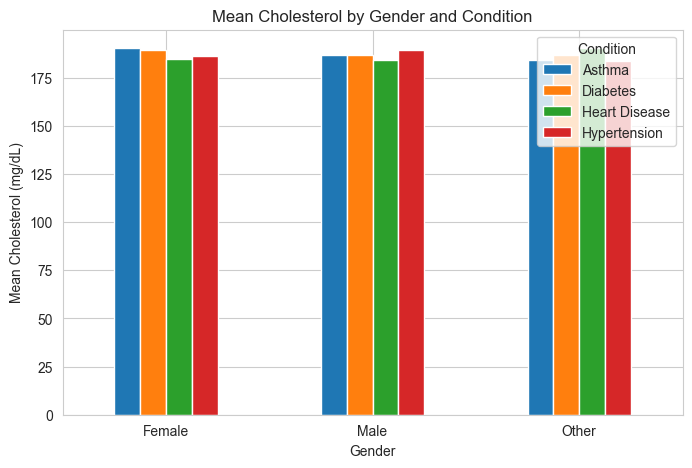

In [30]:
grouped = df.groupby(['Gender', 'Condition'])['Cholesterol'].mean().unstack()

grouped.plot(kind='bar', figsize=(8,5))
plt.title('Mean Cholesterol by Gender and Condition')
plt.xlabel('Gender')
plt.ylabel('Mean Cholesterol (mg/dL)')
plt.legend(title='Condition')
plt.xticks(rotation=0)
plt.show()

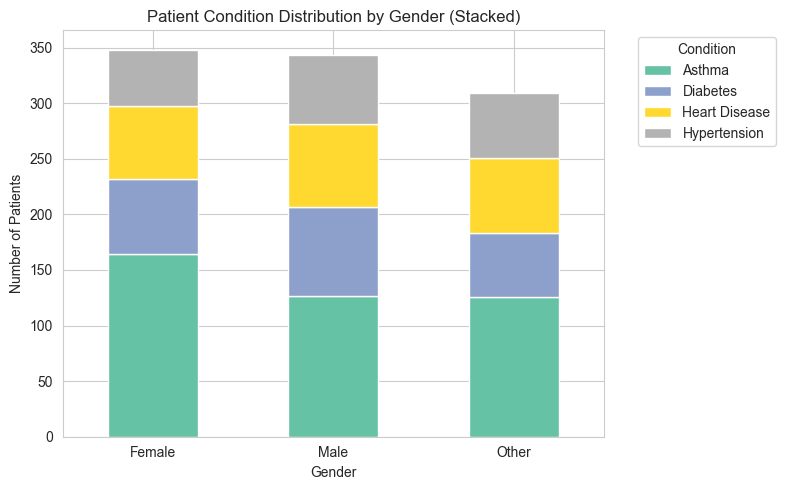

In [31]:
# ── Stacked Bar Chart: Condition distribution by Gender ─────────────────────
condition_gender = df.groupby(['Gender', 'Condition']).size().unstack(fill_value=0)

condition_gender.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='Set2')
plt.title('Patient Condition Distribution by Gender (Stacked)')
plt.xlabel('Gender')
plt.ylabel('Number of Patients')
plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

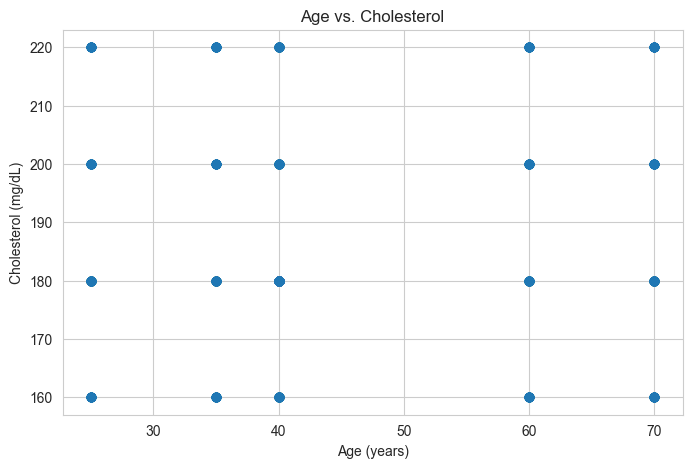

In [32]:
plt.figure(figsize=(8,5))
plt.scatter(df['Age'], df['Cholesterol'], alpha=0.5)
plt.title('Age vs. Cholesterol')
plt.xlabel('Age (years)')
plt.ylabel('Cholesterol (mg/dL)')
plt.grid(True)
plt.show()

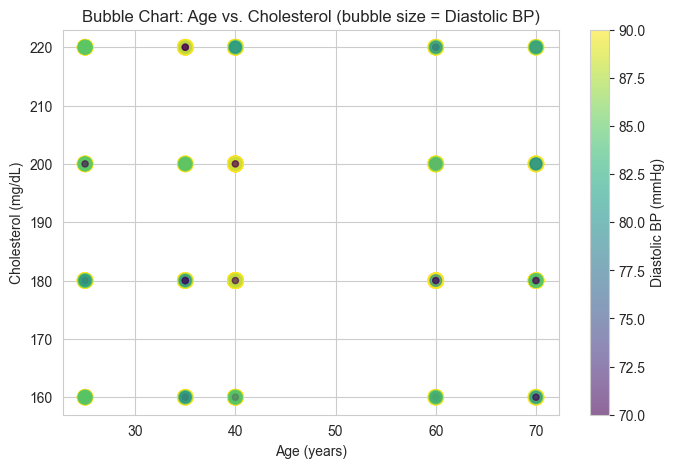

In [33]:
# Scale bubble sizes to a visible range
sizes = (df['Diastolic'] - df['Diastolic'].min()) / (df['Diastolic'].max() - df['Diastolic'].min()) * 100 + 20

plt.figure(figsize=(8,5))
sc = plt.scatter(df['Age'], df['Cholesterol'], s=sizes, alpha=0.6, c=df['Diastolic'], cmap='viridis')
plt.colorbar(sc, label='Diastolic BP (mmHg)')
plt.title('Bubble Chart: Age vs. Cholesterol (bubble size = Diastolic BP)')
plt.xlabel('Age (years)')
plt.ylabel('Cholesterol (mg/dL)')
plt.grid(True)
plt.show()

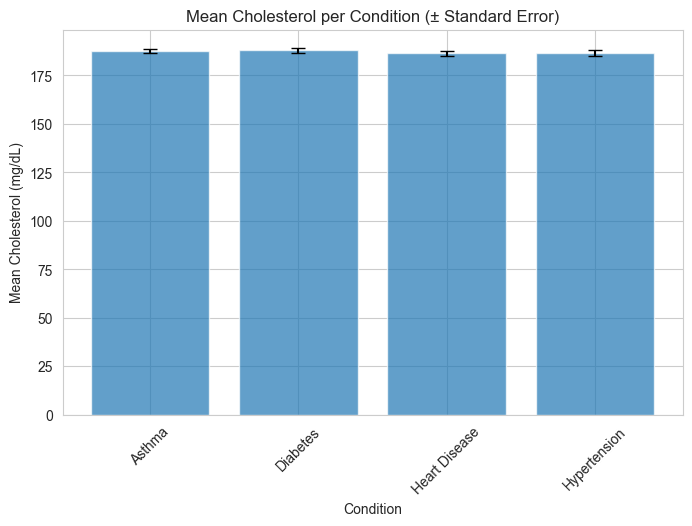

In [34]:
mean_chol = df.groupby('Condition')['Cholesterol'].mean()
sem_chol = df.groupby('Condition')['Cholesterol'].sem()

plt.figure(figsize=(8,5))
plt.bar(mean_chol.index, mean_chol, yerr=sem_chol, capsize=5, alpha=0.7)
plt.title('Mean Cholesterol per Condition (± Standard Error)')
plt.xlabel('Condition')
plt.ylabel('Mean Cholesterol (mg/dL)')
plt.xticks(rotation=45)
plt.show()

In [35]:
fig = px.scatter(df, x='Age', y='Cholesterol', color='Diastolic',
                 hover_data=['Gender', 'Condition', 'Medication'],
                 title='Interactive: Age vs. Cholesterol (color = Diastolic BP)')
fig.show()

## Interactive Visualization – Age vs. Cholesterol (colored by Diastolic BP)

An interactive Plotly scatter plot allows dynamic exploration of the data. Users can hover over points to see detailed patient information (Gender, Condition, Medication) and use the color bar to assess diastolic pressure levels. This tool is useful for identifying outliers and patterns that are not obvious in static plots.

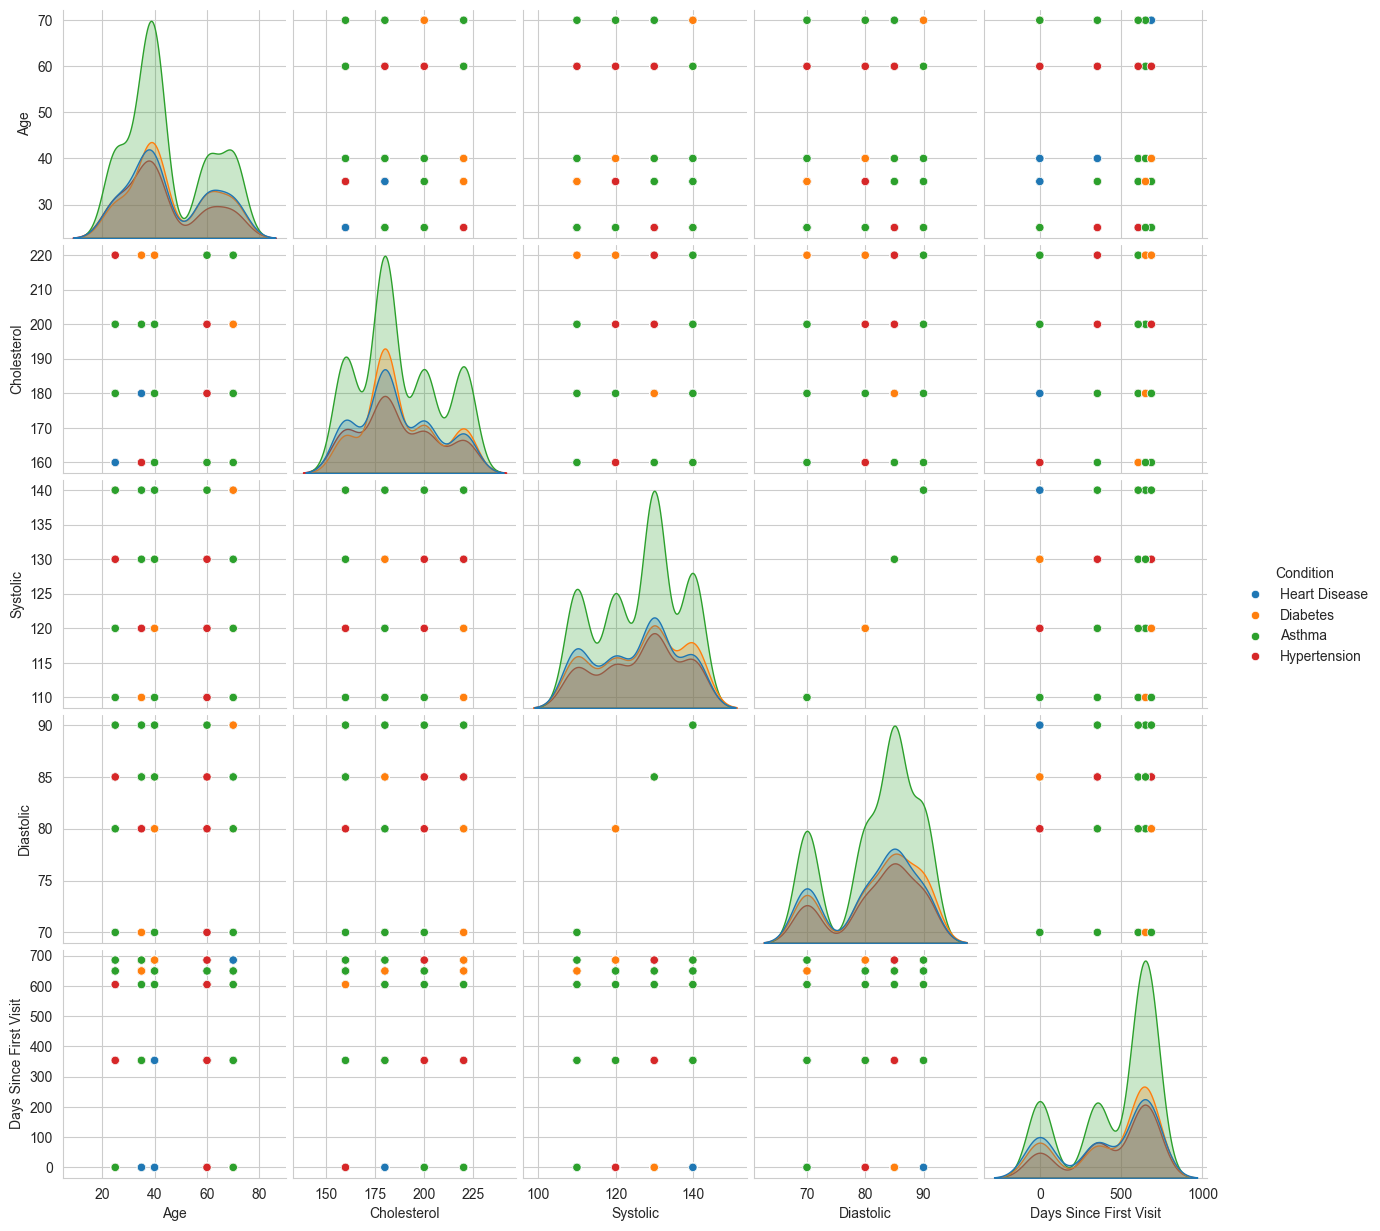

In [36]:
import seaborn as sns
sns.pairplot(df, hue='Condition', vars=['Age', 'Cholesterol', 'Systolic', 'Diastolic', 'Days Since First Visit'])
plt.show()

In [37]:
from scipy.stats import f_oneway
groups = [df[df['Condition']==c]['Cholesterol'] for c in df['Condition'].unique()]
f_oneway(*groups)

F_onewayResult(statistic=np.float64(0.2740150125527175), pvalue=np.float64(0.8441696425086376))

In [38]:
from scipy.stats import ttest_ind
heart = df[df['Condition']=='Heart Disease']['Cholesterol']
asthma = df[df['Condition']=='Asthma']['Cholesterol']
ttest_ind(heart, asthma)

TtestResult(statistic=np.float64(-0.6422843126889327), pvalue=np.float64(0.5209252500433177), df=np.float64(622.0))

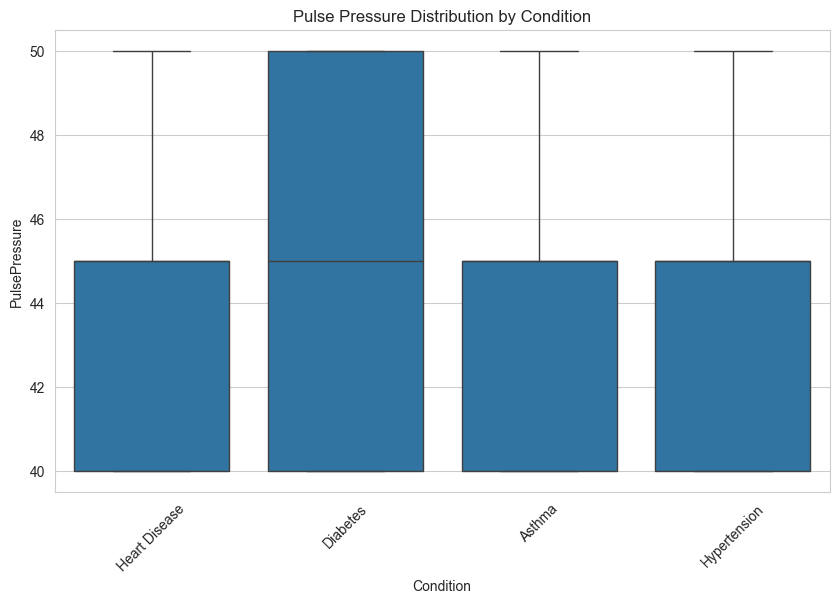

In [39]:
df['PulsePressure'] = df['Systolic'] - df['Diastolic']
sns.boxplot(data=df, x='Condition', y='PulsePressure')
plt.title('Pulse Pressure Distribution by Condition')
plt.xticks(rotation=45)
plt.show()

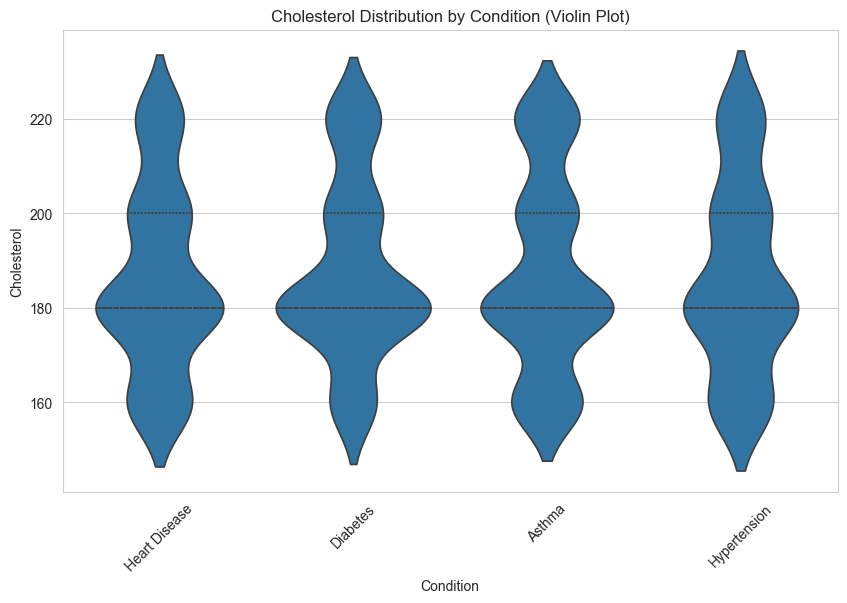

In [40]:
sns.violinplot(data=df, x='Condition', y='Cholesterol', inner='quartile')
plt.title('Cholesterol Distribution by Condition (Violin Plot)')
plt.xticks(rotation=45)
plt.show()

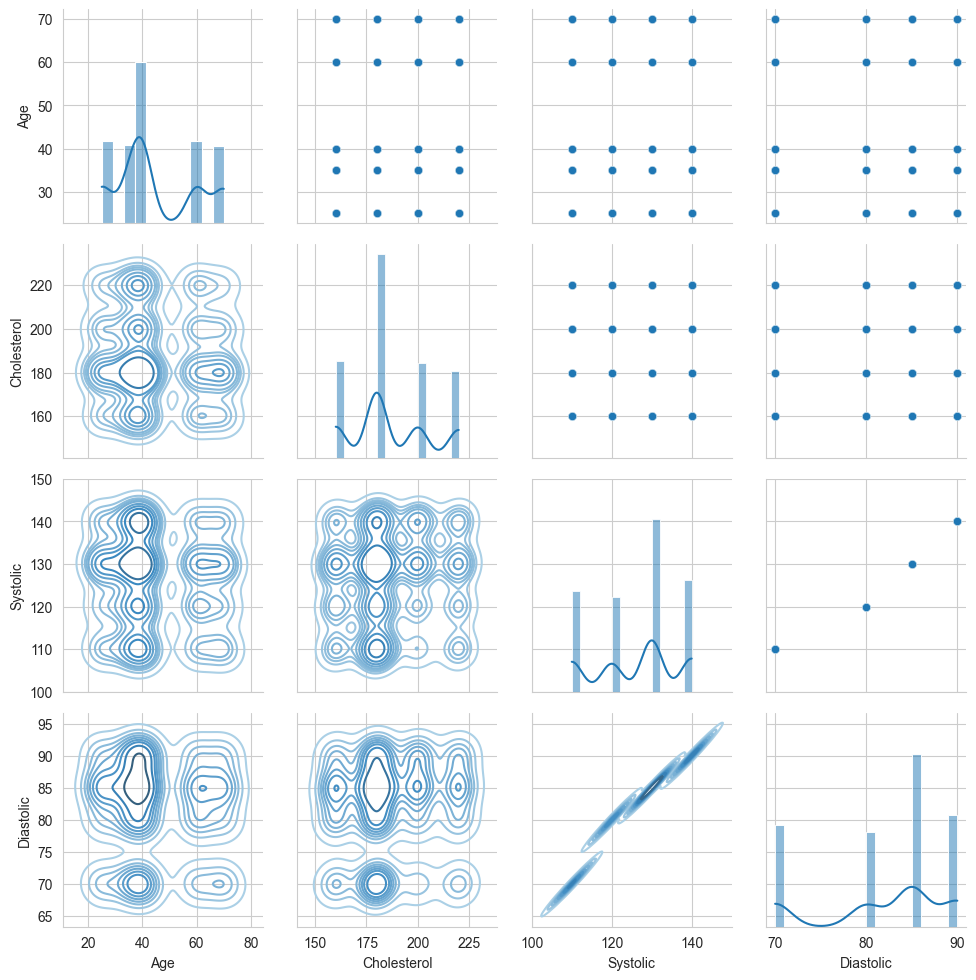

In [41]:
g = sns.PairGrid(df, vars=['Age', 'Cholesterol', 'Systolic', 'Diastolic'])
g.map_upper(sns.scatterplot, alpha=0.5)
g.map_lower(sns.kdeplot, cmap='Blues_d')
g.map_diag(sns.histplot, kde=True)
plt.show()

In [42]:
from scipy.stats import f_oneway

groups = [df[df['Condition'] == c]['Cholesterol'].dropna() for c in df['Condition'].unique()]
f_stat, p_val = f_oneway(*groups)
print(f'ANOVA p-value: {p_val:.4f}')

ANOVA p-value: 0.8442


In [43]:
from scipy.stats import ttest_ind
from itertools import combinations

conditions = df['Condition'].unique()
for (c1, c2) in combinations(conditions, 2):
    t_stat, p = ttest_ind(df[df['Condition']==c1]['Cholesterol'], df[df['Condition']==c2]['Cholesterol'])
    print(f'{c1} vs {c2}: p = {p:.4f}')
# Apply Bonferroni: multiply p by number of comparisons

Heart Disease vs Diabetes: p = 0.4217
Heart Disease vs Asthma: p = 0.5209
Heart Disease vs Hypertension: p = 0.8955
Diabetes vs Asthma: p = 0.8062
Diabetes vs Hypertension: p = 0.5329
Asthma vs Hypertension: p = 0.6521


In [41]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 4.5 MB/s  0:00:02eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Prepare features
X = df[['Age', 'Systolic', 'Diastolic', 'Condition']]
y = df['Cholesterol']

# One‑hot encode Condition
preprocessor = ColumnTransformer(
    [('cat', OneHotEncoder(drop='first'), ['Condition'])],
    remainder='passthrough'
)
X_encoded = preprocessor.fit_transform(X)

# Fit model
model = LinearRegression()
model.fit(X_encoded, y)

# Coefficients
coef_names = preprocessor.get_feature_names_out()
print("Coefficients:")
for name, coef in zip(coef_names, model.coef_):
    print(f"{name}: {coef:.2f}")
print(f"Intercept: {model.intercept_:.2f}")
print(f"R²: {model.score(X_encoded, y):.3f}")

Coefficients:
cat__Condition_Diabetes: 0.39
cat__Condition_Heart Disease: -1.01
cat__Condition_Hypertension: -0.86
remainder__Age: -0.02
remainder__Systolic: 0.33
remainder__Diastolic: -0.35
Intercept: 175.42
R²: 0.004


In [45]:
df['PulsePressure'] = df['Systolic'] - df['Diastolic']

In [46]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = ['Age', 'Cholesterol', 'Systolic', 'Diastolic', 'Days Since First Visit']
X_cluster = StandardScaler().fit_transform(df[features])
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_cluster)

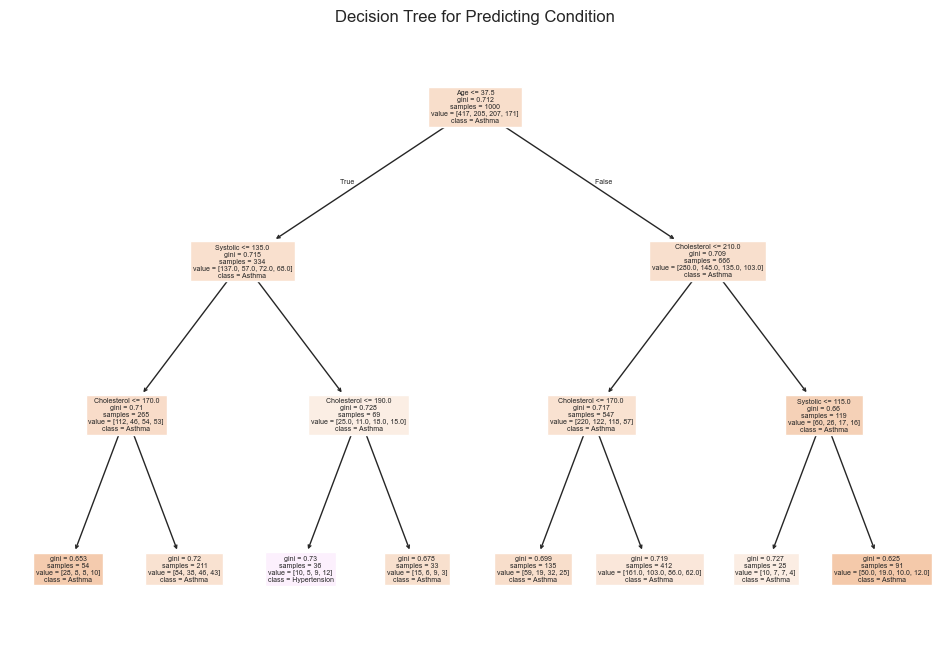

In [47]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

X_tree = df[['Age', 'Cholesterol', 'Systolic', 'Diastolic']]
y_tree = df['Condition']
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_tree, y_tree)

plt.figure(figsize=(12,8))
plot_tree(clf, feature_names=X_tree.columns, class_names=clf.classes_, filled=True)
plt.title('Decision Tree for Predicting Condition')
plt.show()

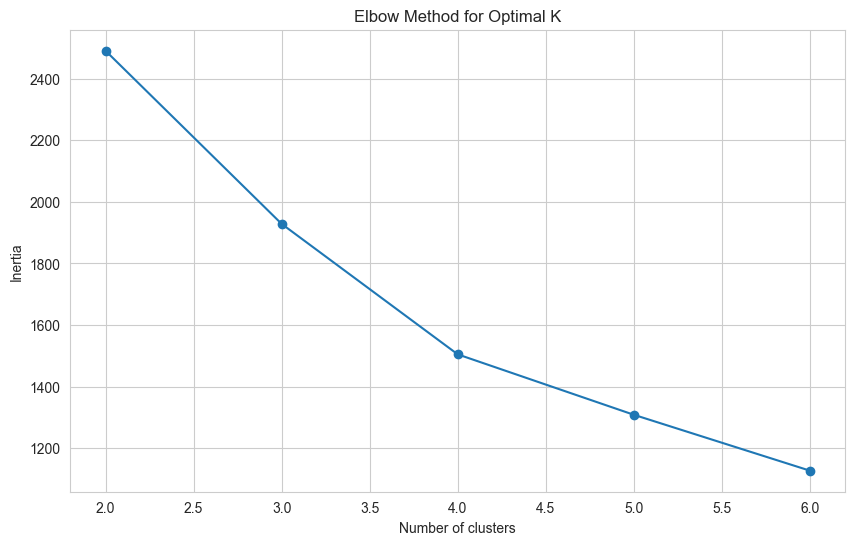

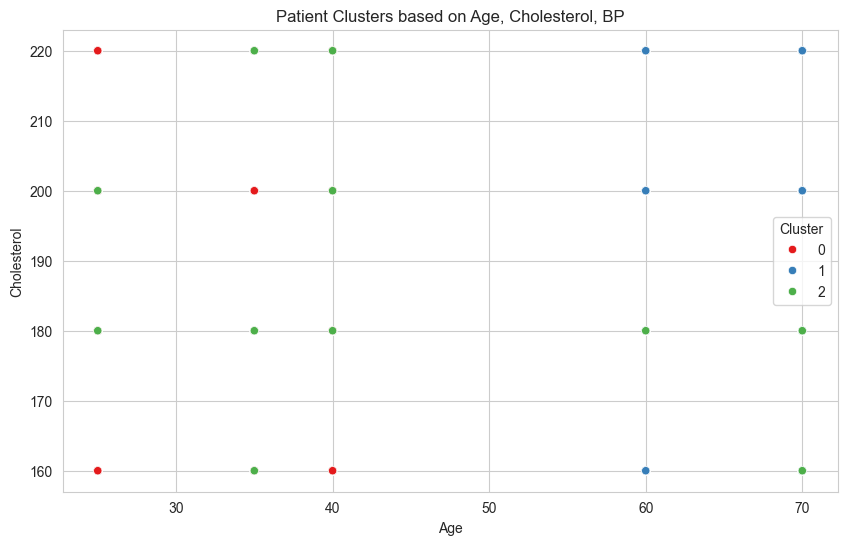

In [48]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = ['Age', 'Cholesterol', 'Systolic', 'Diastolic']
X_cluster = StandardScaler().fit_transform(df[features])

# Determine optimal K using elbow method
inertias = []
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertias.append(kmeans.inertia_)

plt.plot(range(2,7), inertias, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

# Choose K (e.g., 3) and assign clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_cluster)

# Visualize clusters
sns.scatterplot(data=df, x='Age', y='Cholesterol', hue='Cluster', palette='Set1')
plt.title('Patient Clusters based on Age, Cholesterol, BP')
plt.show()

## Phase 3 — FEATURE ENGINEERING

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv('healthcare_cleaned.csv')
print("Shape:", df.shape)
df.head()

df['BP_Ratio'] = df['Systolic'] / df['Diastolic']          
df['Chol_per_Age'] = df['Cholesterol'] / df['Age']         

df['Log_Cholesterol'] = np.log1p(df['Cholesterol'])        
df['Age_Squared'] = df['Age'] ** 2                        

df['Pulse_Pressure'] = df['Systolic'] - df['Diastolic']    
df['Mean_Arterial_Pressure'] = df['Diastolic'] + (df['Pulse_Pressure'] / 3)  

df['Age_Group'] = pd.cut(df['Age'],
                         bins=[0, 30, 45, 60, 120],
                         labels=['Young', 'Middle', 'Senior', 'Elderly'])

df['Chol_Category'] = pd.cut(df['Cholesterol'],
                              bins=[0, 170, 200, 240, 999],
                              labels=['Optimal', 'Normal', 'Borderline', 'High'])

df['BP_Category'] = pd.cut(df['Systolic'],
                            bins=[0, 120, 130, 140, 999],
                            labels=['Normal', 'Elevated', 'Stage1_HTN', 'Stage2_HTN'])

print("New features added:")
print(df[['BP_Ratio', 'Chol_per_Age', 'Pulse_Pressure', 'Mean_Arterial_Pressure',
          'Age_Group', 'Chol_Category', 'BP_Category']].head())

Shape: (1000, 8)
New features added:
   BP_Ratio  Chol_per_Age  Pulse_Pressure  Mean_Arterial_Pressure Age_Group  \
0  1.555556      8.000000            50.0              106.666667     Young   
1  1.500000      5.000000            40.0               93.333333    Middle   
2  1.571429      4.571429            40.0               83.333333    Middle   
3  1.571429      4.500000            40.0               83.333333    Middle   
4  1.571429      4.500000            40.0               83.333333    Middle   

  Chol_Category BP_Category  
0        Normal  Stage1_HTN  
1        Normal      Normal  
2       Optimal      Normal  
3        Normal      Normal  
4        Normal      Normal  


In [ ]:
df['Visit_Week'] = (df['Days Since First Visit'] // 7).astype(int)      
df['Visit_Quarter'] = pd.cut(df['Days Since First Visit'],
                              bins=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

# Mean cholesterol per condition (group‑level statistic for each patient)
df['Mean_Chol_by_Condition'] = df.groupby('Condition')['Cholesterol'].transform('mean')
df['Std_Chol_by_Condition']  = df.groupby('Condition')['Cholesterol'].transform('std')

# Count of patients with same medication (frequency encoding)
df['Medication_Frequency'] = df.groupby('Medication')['Medication'].transform('count')

print(df[['Visit_Week', 'Visit_Quarter', 'Mean_Chol_by_Condition',
          'Medication_Frequency']].head(8))

   Visit_Week Visit_Quarter  Mean_Chol_by_Condition  Medication_Frequency
0          92            Q4              186.280193                   211
1           0            Q1              187.804878                   199
2          86            Q4              187.386091                   211
3          92            Q4              187.804878                   187
4          98            Q4              187.386091                   199
5          50            Q3              186.549708                   211
6          98            Q4              186.549708                   187
7          98            Q4              187.386091                   199


## Mutual Information Feature Selection

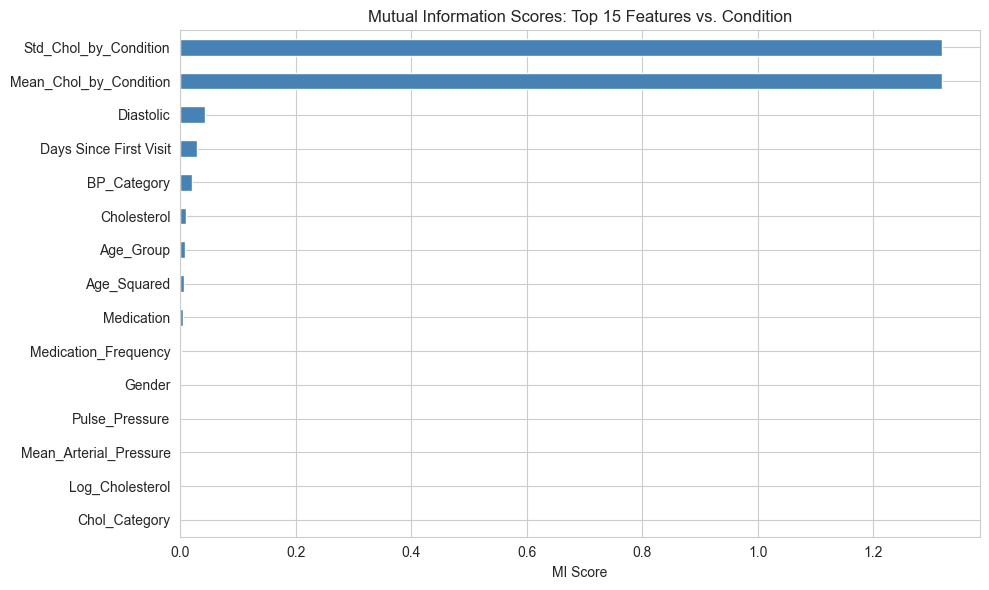


Top 10 features by MI:
Std_Chol_by_Condition     1.319145
Mean_Chol_by_Condition    1.319145
Diastolic                 0.043379
Days Since First Visit    0.028626
BP_Category               0.020909
Cholesterol               0.009939
Age_Group                 0.009094
Age_Squared               0.006334
Medication                0.005324
Medication_Frequency      0.000783
dtype: float64


In [ ]:
# Encode categoricals for MI calculation
df_mi = df.copy()
for col in df_mi.select_dtypes(include=['object', 'category']).columns:
    df_mi[col] = LabelEncoder().fit_transform(df_mi[col].astype(str))

df_mi = df_mi.dropna()

target = 'Condition'
feature_cols = [c for c in df_mi.columns if c != target]

X_mi = df_mi[feature_cols]
y_mi = df_mi[target]

mi_scores = mutual_info_classif(X_mi, y_mi, discrete_features='auto', random_state=42)
mi_series = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
mi_series.head(15).plot(kind='barh', color='steelblue')
plt.title('Mutual Information Scores: Top 15 Features vs. Condition')
plt.xlabel('MI Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 features by MI:")
print(mi_series.head(10))

## PCA – Dimensionality Reduction

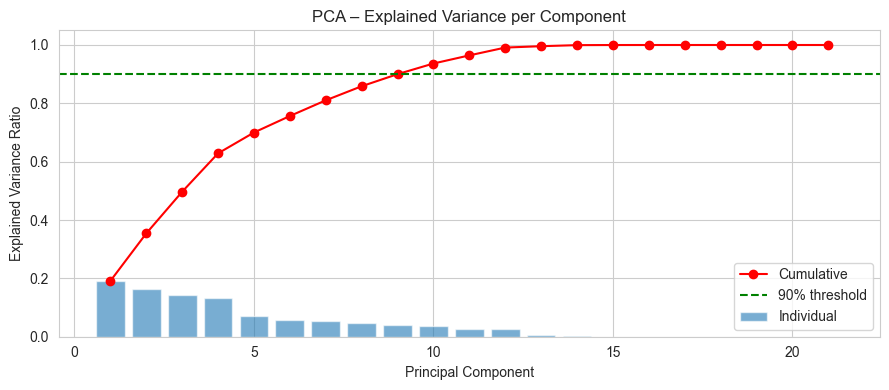

Components needed for 90% variance: 9 out of 21


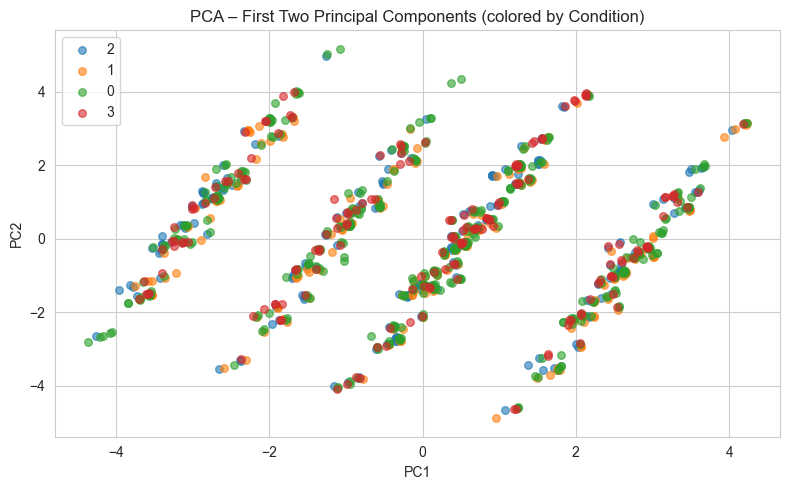

In [ ]:
# Use only numeric engineered features
numeric_features = df_mi.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [c for c in numeric_features if c != target]

X_pca = df_mi[numeric_features]
X_scaled = StandardScaler().fit_transform(X_pca)

pca = PCA(random_state=42)
pca.fit(X_scaled)

# Explained variance plot
cumvar = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(9, 4))
plt.bar(range(1, len(cumvar)+1), pca.explained_variance_ratio_, alpha=0.6, label='Individual')
plt.plot(range(1, len(cumvar)+1), cumvar, 'r-o', label='Cumulative')
plt.axhline(0.90, color='green', linestyle='--', label='90% threshold')
plt.title('PCA – Explained Variance per Component')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.legend()
plt.tight_layout()
plt.show()

n_components_90 = np.argmax(cumvar >= 0.90) + 1
print(f"Components needed for 90% variance: {n_components_90} out of {len(numeric_features)}")

# Apply PCA with chosen n_components
pca_final = PCA(n_components=n_components_90, random_state=42)
X_reduced = pca_final.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_reduced, columns=[f'PC{i+1}' for i in range(n_components_90)])
df_pca['Condition'] = df_mi[target].values

# Visualize first two PCs
plt.figure(figsize=(8, 5))
for cond in df_pca['Condition'].unique():
    subset = df_pca[df_pca['Condition'] == cond]
    plt.scatter(subset['PC1'], subset['PC2'], label=cond, alpha=0.6, s=30)
plt.title('PCA – First Two Principal Components (colored by Condition)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()

## Phase 4 (BONUS) – Web Scraping

In [1]:
# Uses the hidden API that bama.ir's own frontend calls.

import requests
import pandas as pd
import re
import time

session = requests.Session()
session.headers.update({
    'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/145.0.0.0 Safari/537.36',
    'Accept': 'application/json, text/plain, */*',
    'Accept-Language': 'en-US,en;q=0.9',
    'Referer': 'https://bama.ir/',
})

# cookie were copied from browser
session.headers.update({
    'Cookie': 'auth.globalUserContextId=2a6bb378-2a79-4b46-ac37-1f6d3f96053d; auth.strategy=user; x-device-target=desktop; evonex-locale=fa'
})

# API endpoint (found via browser DevTools)
API_URL = "https://bama.ir/cad/api/search?vehicle=samand%2Clx&pageIndex={page}"

def clean_text(text):
    """Remove unwanted characters from text."""
    if text is None:
        return None
    return text.strip().replace('\u200c', '').replace('\xa0', ' ')

def extract_number(value):
    """Extract numeric value from price/mileage strings (e.g., '380,000,000' -> 380000000)."""
    if value is None:
        return None
    cleaned = re.sub(r'[^\d]', '', str(value))
    return int(cleaned) if cleaned else None

records = []

for page in range(1, 4):  # API shows total_pages = 3
    url = API_URL.format(page=page)
    print(f"Fetching page {page}: {url}")
    try:
        resp = session.get(url, timeout=15)
        resp.raise_for_status()
        data = resp.json()
    except Exception as e:
        print(f"API request failed for page {page}: {e}")
        continue

    # Extract ad list from JSON response
    ads = data.get('data', {}).get('ads', [])
    if not ads:
        print(f"No ads found on page {page}")
        continue

    for ad in ads:
        detail = ad.get('detail', {})
        specs = ad.get('specs', {})
        price_info = ad.get('price', {})

        year_text = detail.get('year')
        # Filter: keep only cars manufactured after 1385 (Solar Hijri)
        if year_text:
            try:
                year_num = int(year_text)
                if year_num <= 1385:
                    continue
            except ValueError:
                pass

        records.append({
            'title': clean_text(detail.get('title')),
            'year': year_text,
            'mileage': extract_number(detail.get('mileage')),
            'price': extract_number(price_info.get('price')),
            'location': clean_text(detail.get('location')),
            'color': clean_text(detail.get('color')),
            'transmission': clean_text(detail.get('transmission')),
            'fuel': clean_text(detail.get('fuel')),
            'engine': clean_text(specs.get('engine')),
            'description': clean_text(detail.get('description')),
            'image_url': detail.get('image'),
        })

    time.sleep(1)  # polite delay

print(f"Scraped {len(records)} records")
df_cars = pd.DataFrame(records)
df_cars.head()

if not df_cars.empty:
    df_cars.to_excel('samand_cars_bama.xlsx', index=False)
else:
    print("errrrrrr")

Fetching page 1: https://bama.ir/cad/api/search?vehicle=samand%2Clx&pageIndex=1
Fetching page 2: https://bama.ir/cad/api/search?vehicle=samand%2Clx&pageIndex=2
Fetching page 3: https://bama.ir/cad/api/search?vehicle=samand%2Clx&pageIndex=3
Scraped 85 records
